In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
.appName("S3Spark") \
.config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.1") \
.getOrCreate()


In [6]:
spark

In [7]:
spark._jsc.hadoopConfiguration().set("fs.s3a.access.key", "XXXXXXXXX")
spark._jsc.hadoopConfiguration().set("fs.s3a.secret.key", "XXXXX")
spark._jsc.hadoopConfiguration().set("fs.s3a.endpoint", "s3.amazonaws.com")


In [8]:
match_event_df = spark.read.csv(
    "s3a://uefa-euro-2020-data-analysis/dataset/Match events.csv",
    header=True,
    inferSchema=True
)

match_event_df.show()


+-------+------------+---------------+-------------------+------+-----+------------+----------+--------+------------+----------+--------------------+-------------------+
|MatchID|HomeTeamName|   AwayTeamName|              Event|Minute|Phase|InjuryMinute|TeamFromID|TeamToID|PlayerFromID|PlayerToID|                Time|MatchEventAttribute|
+-------+------------+---------------+-------------------+------+-----+------------+----------+--------+------------+----------+--------------------+-------------------+
|2024442|     Austria|North Macedonia|     StartFirstHalf|     0|    1|           0|        NA|      NA|          NA|        NA|2021-06-13 16:00:...|                 NA|
|2024442|     Austria|North Macedonia|               Foul|     4|    1|           0|     59205|       8|   250039878| 250003976|2021-06-13 16:03:...|                 NA|
|2024442|     Austria|North Macedonia|           FreeKick|     4|    1|           0|         8|      NA|     1909713|        NA|2021-06-13 16:03:...| 

In [9]:
import pandas as pd

In [10]:
bucket = 'uefa-euro-2020-data-analysis/dataset'
data_key = 'Match events.csv'
data_location = 's3://{}/{}'.format(bucket, data_key)

df = pd.read_csv(data_location)

df.head()



,MatchID,HomeTeamName,AwayTeamName,Event,Minute,Phase,InjuryMinute,TeamFromID,TeamToID,PlayerFromID,PlayerToID,Time,MatchEventAttribute
0,2024442,Austria,North Macedonia,StartFirstHalf,0,1,0,NaN,NaN,NaN,NaN,2021-06-13T16:00:20.217,NaN
1,2024442,Austria,North Macedonia,Foul,4,1,0,59205.0,8.0,250039878.0,250003976.0,2021-06-13T16:03:45.897,NaN
2,2024442,Austria,North Macedonia,FreeKick,4,1,0,8.0,NaN,1909713.0,NaN,2021-06-13T16:03:56.853,NaN
3,2024442,Austria,North Macedonia,Foul,5,1,0,59205.0,8.0,250004363.0,101177.0,2021-06-13T16:04:44.217,NaN
4,2024442,Austria,North Macedonia,FreeKick,5,1,0,8.0,NaN,250065408.0,NaN,2021-06-13T16:04:54.533,NaN


In [11]:
df = df.astype(str)
spark_df = spark.createDataFrame(df)


In [12]:
spark_df.show(5)


+-------+------------+---------------+--------------+------+-----+------------+----------+--------+------------+-----------+--------------------+-------------------+
|MatchID|HomeTeamName|   AwayTeamName|         Event|Minute|Phase|InjuryMinute|TeamFromID|TeamToID|PlayerFromID| PlayerToID|                Time|MatchEventAttribute|
+-------+------------+---------------+--------------+------+-----+------------+----------+--------+------------+-----------+--------------------+-------------------+
|2024442|     Austria|North Macedonia|StartFirstHalf|     0|    1|           0|       nan|     nan|         nan|        nan|2021-06-13T16:00:...|                nan|
|2024442|     Austria|North Macedonia|          Foul|     4|    1|           0|   59205.0|     8.0| 250039878.0|250003976.0|2021-06-13T16:03:...|                nan|
|2024442|     Austria|North Macedonia|      FreeKick|     4|    1|           0|       8.0|     nan|   1909713.0|        nan|2021-06-13T16:03:...|                nan|
|202

In [13]:
spark_df.printSchema()

root
 |-- MatchID: string (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- Event: string (nullable = true)
 |-- Minute: string (nullable = true)
 |-- Phase: string (nullable = true)
 |-- InjuryMinute: string (nullable = true)
 |-- TeamFromID: string (nullable = true)
 |-- TeamToID: string (nullable = true)
 |-- PlayerFromID: string (nullable = true)
 |-- PlayerToID: string (nullable = true)
 |-- Time: string (nullable = true)
 |-- MatchEventAttribute: string (nullable = true)



In [14]:
from pyspark.sql.functions import col

spark_df = spark_df \
.withColumn("MatchID", col("MatchID").cast("int")) \
.withColumn("Minute", col("Minute").cast("int")) \
.withColumn("Phase", col("Phase").cast("int")) \
.withColumn("InjuryMinute", col("InjuryMinute").cast("int")) \
.withColumn("TeamFromID", col("TeamFromID").cast("int")) \
.withColumn("TeamToID", col("TeamToID").cast("int")) \
.withColumn("PlayerFromID", col("PlayerFromID").cast("int")) \
.withColumn("PlayerToID", col("PlayerToID").cast("int")) \
.withColumn("Time", col("Time").cast("timestamp"))

In [15]:
spark_df.printSchema()

root
 |-- MatchID: integer (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- Event: string (nullable = true)
 |-- Minute: integer (nullable = true)
 |-- Phase: integer (nullable = true)
 |-- InjuryMinute: integer (nullable = true)
 |-- TeamFromID: integer (nullable = true)
 |-- TeamToID: integer (nullable = true)
 |-- PlayerFromID: integer (nullable = true)
 |-- PlayerToID: integer (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- MatchEventAttribute: string (nullable = true)



In [16]:
spark_df.show(5)

+-------+------------+---------------+--------------+------+-----+------------+----------+--------+------------+----------+--------------------+-------------------+
|MatchID|HomeTeamName|   AwayTeamName|         Event|Minute|Phase|InjuryMinute|TeamFromID|TeamToID|PlayerFromID|PlayerToID|                Time|MatchEventAttribute|
+-------+------------+---------------+--------------+------+-----+------------+----------+--------+------------+----------+--------------------+-------------------+
|2024442|     Austria|North Macedonia|StartFirstHalf|     0|    1|           0|      null|    null|        null|      null|2021-06-13 16:00:...|                nan|
|2024442|     Austria|North Macedonia|          Foul|     4|    1|           0|     59205|       8|   250039878| 250003976|2021-06-13 16:03:...|                nan|
|2024442|     Austria|North Macedonia|      FreeKick|     4|    1|           0|         8|    null|     1909713|      null|2021-06-13 16:03:...|                nan|
|2024442| 

In [17]:
bucket = 'uefa-euro-2020-data-analysis/dataset'
data_key = 'Match information.csv'
data_location = 's3://{}/{}'.format(bucket, data_key)

df_1 = pd.read_csv(data_location)

df_1.head()


,HomeTeamName,AwayTeamName,DateandTimeCET,MatchID,RoundName,MatchDay,Session,MatchMinute,InjuryTime,NumberOfPhases,Phase,ScoreHome,ScoreAway,MatchStatus,StadiumID,RefereeWebName,AssistantRefereeWebName,Humidity,Temperature,WindSpeed
0,Turkey,Italy,2021-06-11T21:00:00,2024447,final tournament,1,1,90,4,2,2,0,3,Played,57775,Makkelie,Steegstra,63,24,9
1,Wales,Switzerland,2021-06-12T15:00:00,2024448,final tournament,1,2,90,6,2,2,1,1,Played,250002745,Turpin,Danos,45,29,23
2,Denmark,Finland,2021-06-12T18:00:00,2024449,final tournament,1,2,90,5,2,2,0,1,Played,63462,Taylor,Beswick,48,17,32
3,Belgium,Russia,2021-06-12T21:00:00,2024450,final tournament,1,2,90,2,2,2,3,0,Played,250003363,Mateu Lahoz,Cebrián Devís,23,19,8
4,England,Croatia,2021-06-13T15:00:00,2024451,final tournament,1,3,90,5,2,2,1,0,Played,1100043,Orsato,Giallatini,46,27,11


In [18]:
df_1 = df_1.astype(str)
spark_df_1 = spark.createDataFrame(df_1)

In [19]:
spark_df_1.show(5)

+------------+------------+-------------------+-------+----------------+--------+-------+-----------+----------+--------------+-----+---------+---------+-----------+---------+--------------+-----------------------+--------+-----------+---------+
|HomeTeamName|AwayTeamName|     DateandTimeCET|MatchID|       RoundName|MatchDay|Session|MatchMinute|InjuryTime|NumberOfPhases|Phase|ScoreHome|ScoreAway|MatchStatus|StadiumID|RefereeWebName|AssistantRefereeWebName|Humidity|Temperature|WindSpeed|
+------------+------------+-------------------+-------+----------------+--------+-------+-----------+----------+--------------+-----+---------+---------+-----------+---------+--------------+-----------------------+--------+-----------+---------+
|      Turkey|       Italy|2021-06-11T21:00:00|2024447|final tournament|       1|      1|         90|         4|             2|    2|        0|        3|     Played|    57775|      Makkelie|              Steegstra|      63|         24|        9|
|       Wales| S

In [20]:
bucket = 'uefa-euro-2020-data-analysis/dataset'
data_key = 'Match line-ups.csv'
data_location = 's3://{}/{}'.format(bucket, data_key)

df_2 = pd.read_csv(data_location)

df_2.head()


,MatchID,HomeTeamName,AwayTeamName,IsPitch,IsBench,IsStaff,Country,ID,OfficialName,OfficialSurname,ShortName,Role,JerseyNumber,IsGoalkeeper,JerseyName,IsCaptain,TacticX,TacticY,Numorder,IsBooked
0,2024442,Austria,North Macedonia,True,False,False,Austria,250056875,Daniel,Bachmann,Bachmann,goalkeepers,13,True,Bachmann,False,150,504,1,NaN
1,2024442,Austria,North Macedonia,True,False,False,Austria,101177,Andreas,Ulmer,Ulmer,defenders,2,False,Ulmer,False,562,153,2,NaN
2,2024442,Austria,North Macedonia,True,False,False,Austria,1909713,Aleksandar,Dragovic,Dragovic,defenders,3,False,Dragovic,False,345,737,3,NaN
3,2024442,Austria,North Macedonia,True,False,False,Austria,250020234,Martin,Hinteregger,Hinteregger,defenders,4,False,Hinteregger,False,370,317,4,NaN
4,2024442,Austria,North Macedonia,True,False,False,Austria,1906540,David,Alaba,Alaba,defenders,8,False,Alaba,True,328,455,5,NaN


In [21]:
df_2 = df_2.astype(str)
spark_df_2 = spark.createDataFrame(df_2)

In [22]:
spark_df_2.show(5)

+-------+------------+---------------+-------+-------+-------+-------+---------+------------+---------------+-----------+-----------+------------+------------+-----------+---------+-------+-------+--------+--------+
|MatchID|HomeTeamName|   AwayTeamName|IsPitch|IsBench|IsStaff|Country|       ID|OfficialName|OfficialSurname|  ShortName|       Role|JerseyNumber|IsGoalkeeper| JerseyName|IsCaptain|TacticX|TacticY|Numorder|IsBooked|
+-------+------------+---------------+-------+-------+-------+-------+---------+------------+---------------+-----------+-----------+------------+------------+-----------+---------+-------+-------+--------+--------+
|2024442|     Austria|North Macedonia|   True|  False|  False|Austria|250056875|      Daniel|       Bachmann|   Bachmann|goalkeepers|          13|        True|   Bachmann|    False|    150|    504|       1|     nan|
|2024442|     Austria|North Macedonia|   True|  False|  False|Austria|   101177|     Andreas|          Ulmer|      Ulmer|  defenders|   

In [23]:
bucket = 'uefa-euro-2020-data-analysis/dataset'
data_key = 'Match player statistics.csv'
data_location = 's3://{}/{}'.format(bucket, data_key)

df_3 = pd.read_csv(data_location)

df_3.head()

,MatchID,HomeTeamName,AwayTeamName,PlayerID,PlayerName,PlayerSurname,IsGoalkeeper,PlayedTime,StatsID,StatsName,Value,Rank
0,2024442,Austria,North Macedonia,98843,Julian,Baumgartlinger,False,112,1,Goals,0,5
1,2024442,Austria,North Macedonia,98843,Julian,Baumgartlinger,False,112,3,Total Attempts,0,13
2,2024442,Austria,North Macedonia,98843,Julian,Baumgartlinger,False,112,4,Attempts on target,0,8
3,2024442,Austria,North Macedonia,98843,Julian,Baumgartlinger,False,112,5,Attempts off target,0,6
4,2024442,Austria,North Macedonia,98843,Julian,Baumgartlinger,False,112,6,Attempts against woodwork,0,1


In [26]:
df_3 = df_3.astype(str)
spark_df_3 = spark.createDataFrame(df_3)

In [27]:
spark_df_3.show(5)

+-------+------------+---------------+--------+----------+--------------+------------+----------+-------+--------------------+-----+----+
|MatchID|HomeTeamName|   AwayTeamName|PlayerID|PlayerName| PlayerSurname|IsGoalkeeper|PlayedTime|StatsID|           StatsName|Value|Rank|
+-------+------------+---------------+--------+----------+--------------+------------+----------+-------+--------------------+-----+----+
|2024442|     Austria|North Macedonia|   98843|    Julian|Baumgartlinger|       False|       112|      1|               Goals|    0|   5|
|2024442|     Austria|North Macedonia|   98843|    Julian|Baumgartlinger|       False|       112|      3|      Total Attempts|    0|  13|
|2024442|     Austria|North Macedonia|   98843|    Julian|Baumgartlinger|       False|       112|      4|  Attempts on target|    0|   8|
|2024442|     Austria|North Macedonia|   98843|    Julian|Baumgartlinger|       False|       112|      5| Attempts off target|    0|   6|
|2024442|     Austria|North Macedo

In [28]:
bucket = 'uefa-euro-2020-data-analysis/dataset'
data_key = 'Match team statistics.csv'
data_location = 's3://{}/{}'.format(bucket, data_key)

df_4 = pd.read_csv(data_location)

df_4.head()

,MatchID,HomeTeamName,AwayTeamName,TeamID,TeamName,IsHomeTeam,IsAwayTeam,StatsID,StatsName,Value,Rank
0,2024442,Austria,North Macedonia,8,Austria,True,False,1,Goals,3,1
1,2024442,Austria,North Macedonia,8,Austria,True,False,2,Ball Possession,60,1
2,2024442,Austria,North Macedonia,8,Austria,True,False,3,Total Attempts,11,1
3,2024442,Austria,North Macedonia,8,Austria,True,False,4,Attempts on target,7,1
4,2024442,Austria,North Macedonia,8,Austria,True,False,5,Attempts off target,2,2


In [29]:
df_4 = df_4.astype(str)
spark_df_4 = spark.createDataFrame(df_4)

In [30]:
spark_df_4.show(5)

+-------+------------+---------------+------+--------+----------+----------+-------+-------------------+-----+----+
|MatchID|HomeTeamName|   AwayTeamName|TeamID|TeamName|IsHomeTeam|IsAwayTeam|StatsID|          StatsName|Value|Rank|
+-------+------------+---------------+------+--------+----------+----------+-------+-------------------+-----+----+
|2024442|     Austria|North Macedonia|     8| Austria|      True|     False|      1|              Goals|    3|   1|
|2024442|     Austria|North Macedonia|     8| Austria|      True|     False|      2|    Ball Possession|   60|   1|
|2024442|     Austria|North Macedonia|     8| Austria|      True|     False|      3|     Total Attempts|   11|   1|
|2024442|     Austria|North Macedonia|     8| Austria|      True|     False|      4| Attempts on target|    7|   1|
|2024442|     Austria|North Macedonia|     8| Austria|      True|     False|      5|Attempts off target|    2|   2|
+-------+------------+---------------+------+--------+----------+-------

In [31]:
bucket = 'uefa-euro-2020-data-analysis/dataset'
data_key = 'Pre-match information.csv'
data_location = 's3://{}/{}'.format(bucket, data_key)

df_5 = pd.read_csv(data_location)

df_5.head()

,MatchID,HomeTeamName,AwayTeamName,IsHomeTeam,IsAwayTeam,IsStaff,Country,ID,OfficialName,OfficialSurname,JerseyName,ShortName,GoalScored,CleanSheet,MatchPlayed,SuspendedIfBooked,Role
0,2024442,Austria,North Macedonia,True,False,False,Austria,98843,Julian,Baumgartlinger,Baumgartlinger,Baumgartlinger,0.0,NaN,Baumgartlinger,False,Midfield
1,2024442,Austria,North Macedonia,True,False,False,Austria,101177,Andreas,Ulmer,Ulmer,Ulmer,0.0,NaN,Ulmer,False,Defender
2,2024442,Austria,North Macedonia,True,False,False,Austria,103354,Stefan,Ilsanker,Ilsanker,Ilsanker,0.0,NaN,Ilsanker,False,Midfield
3,2024442,Austria,North Macedonia,True,False,False,Austria,1903428,Marko,Arnautovic,Arnautovic,Arnautovic,0.0,NaN,Arnautovic,False,Forward
4,2024442,Austria,North Macedonia,True,False,False,Austria,1906540,David,Alaba,Alaba,Alaba,0.0,NaN,Alaba,False,Defender


In [32]:
df_5 = df_5.astype(str)
spark_df_5 = spark.createDataFrame(df_5)

In [33]:
spark_df_5.show(5)

+-------+------------+---------------+----------+----------+-------+-------+-------+------------+---------------+--------------+--------------+----------+----------+--------------+-----------------+--------+
|MatchID|HomeTeamName|   AwayTeamName|IsHomeTeam|IsAwayTeam|IsStaff|Country|     ID|OfficialName|OfficialSurname|    JerseyName|     ShortName|GoalScored|CleanSheet|   MatchPlayed|SuspendedIfBooked|    Role|
+-------+------------+---------------+----------+----------+-------+-------+-------+------------+---------------+--------------+--------------+----------+----------+--------------+-----------------+--------+
|2024442|     Austria|North Macedonia|      True|     False|  False|Austria|  98843|      Julian| Baumgartlinger|Baumgartlinger|Baumgartlinger|       0.0|       nan|Baumgartlinger|            False|Midfield|
|2024442|     Austria|North Macedonia|      True|     False|  False|Austria| 101177|     Andreas|          Ulmer|         Ulmer|         Ulmer|       0.0|       nan|   

In [34]:
spark_df_1.printSchema()

root
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- DateandTimeCET: string (nullable = true)
 |-- MatchID: string (nullable = true)
 |-- RoundName: string (nullable = true)
 |-- MatchDay: string (nullable = true)
 |-- Session: string (nullable = true)
 |-- MatchMinute: string (nullable = true)
 |-- InjuryTime: string (nullable = true)
 |-- NumberOfPhases: string (nullable = true)
 |-- Phase: string (nullable = true)
 |-- ScoreHome: string (nullable = true)
 |-- ScoreAway: string (nullable = true)
 |-- MatchStatus: string (nullable = true)
 |-- StadiumID: string (nullable = true)
 |-- RefereeWebName: string (nullable = true)
 |-- AssistantRefereeWebName: string (nullable = true)
 |-- Humidity: string (nullable = true)
 |-- Temperature: string (nullable = true)
 |-- WindSpeed: string (nullable = true)



In [35]:
from pyspark.sql.functions import col

spark_df_1 = spark_df_1 \
.withColumn("DateandTimeCET", col("DateandTimeCET").cast("timestamp")) \
.withColumn("MatchID", col("MatchID").cast("int")) \
.withColumn("MatchDay", col("MatchDay").cast("int")) \
.withColumn("Session", col("Session").cast("int")) \
.withColumn("MatchMinute", col("MatchMinute").cast("int")) \
.withColumn("InjuryTime", col("InjuryTime").cast("int")) \
.withColumn("NumberOfPhases", col("NumberOfPhases").cast("int")) \
.withColumn("Phase", col("Phase").cast("int")) \
.withColumn("ScoreHome", col("ScoreHome").cast("int")) \
.withColumn("ScoreAway", col("ScoreAway").cast("int")) \
.withColumn("StadiumID", col("StadiumID").cast("int")) \
.withColumn("Humidity", col("Humidity").cast("int")) \
.withColumn("Temperature", col("Temperature").cast("int")) \
.withColumn("WindSpeed", col("WindSpeed").cast("int"))

In [36]:
spark_df_1.printSchema()

root
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- DateandTimeCET: timestamp (nullable = true)
 |-- MatchID: integer (nullable = true)
 |-- RoundName: string (nullable = true)
 |-- MatchDay: integer (nullable = true)
 |-- Session: integer (nullable = true)
 |-- MatchMinute: integer (nullable = true)
 |-- InjuryTime: integer (nullable = true)
 |-- NumberOfPhases: integer (nullable = true)
 |-- Phase: integer (nullable = true)
 |-- ScoreHome: integer (nullable = true)
 |-- ScoreAway: integer (nullable = true)
 |-- MatchStatus: string (nullable = true)
 |-- StadiumID: integer (nullable = true)
 |-- RefereeWebName: string (nullable = true)
 |-- AssistantRefereeWebName: string (nullable = true)
 |-- Humidity: integer (nullable = true)
 |-- Temperature: integer (nullable = true)
 |-- WindSpeed: integer (nullable = true)



In [37]:
spark_df_2.printSchema()

root
 |-- MatchID: string (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- IsPitch: string (nullable = true)
 |-- IsBench: string (nullable = true)
 |-- IsStaff: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- ID: string (nullable = true)
 |-- OfficialName: string (nullable = true)
 |-- OfficialSurname: string (nullable = true)
 |-- ShortName: string (nullable = true)
 |-- Role: string (nullable = true)
 |-- JerseyNumber: string (nullable = true)
 |-- IsGoalkeeper: string (nullable = true)
 |-- JerseyName: string (nullable = true)
 |-- IsCaptain: string (nullable = true)
 |-- TacticX: string (nullable = true)
 |-- TacticY: string (nullable = true)
 |-- Numorder: string (nullable = true)
 |-- IsBooked: string (nullable = true)



In [38]:
from pyspark.sql.functions import col

spark_df_2 = spark_df_2 \
.withColumn("MatchID", col("MatchID").cast("int")) \
.withColumn("ID", col("ID").cast("int")) \
.withColumn("JerseyNumber", col("JerseyNumber").cast("int")) \
.withColumn("TacticX", col("TacticX").cast("int")) \
.withColumn("TacticY", col("TacticY").cast("int")) \
.withColumn("Numorder", col("Numorder").cast("int")) \
.withColumn("IsPitch", col("IsPitch").cast("boolean")) \
.withColumn("IsBench", col("IsBench").cast("boolean")) \
.withColumn("IsStaff", col("IsStaff").cast("boolean"))

In [39]:
spark_df_2.printSchema()

root
 |-- MatchID: integer (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- IsPitch: boolean (nullable = true)
 |-- IsBench: boolean (nullable = true)
 |-- IsStaff: boolean (nullable = true)
 |-- Country: string (nullable = true)
 |-- ID: integer (nullable = true)
 |-- OfficialName: string (nullable = true)
 |-- OfficialSurname: string (nullable = true)
 |-- ShortName: string (nullable = true)
 |-- Role: string (nullable = true)
 |-- JerseyNumber: integer (nullable = true)
 |-- IsGoalkeeper: string (nullable = true)
 |-- JerseyName: string (nullable = true)
 |-- IsCaptain: string (nullable = true)
 |-- TacticX: integer (nullable = true)
 |-- TacticY: integer (nullable = true)
 |-- Numorder: integer (nullable = true)
 |-- IsBooked: string (nullable = true)



In [40]:
spark_df_3.printSchema()

root
 |-- MatchID: string (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- PlayerID: string (nullable = true)
 |-- PlayerName: string (nullable = true)
 |-- PlayerSurname: string (nullable = true)
 |-- IsGoalkeeper: string (nullable = true)
 |-- PlayedTime: string (nullable = true)
 |-- StatsID: string (nullable = true)
 |-- StatsName: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Rank: string (nullable = true)



In [41]:
from pyspark.sql.functions import col

spark_df_3 = spark_df_3 \
.withColumn("MatchID", col("MatchID").cast("int")) \
.withColumn("PlayerID", col("PlayerID").cast("int")) \
.withColumn("PlayedTime", col("PlayedTime").cast("int")) \
.withColumn("StatsID", col("StatsID").cast("int")) \
.withColumn("Rank", col("Rank").cast("int")) \
.withColumn("IsGoalkeeper", col("IsGoalkeeper").cast("boolean"))

In [42]:
spark_df_3.printSchema()

root
 |-- MatchID: integer (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- PlayerID: integer (nullable = true)
 |-- PlayerName: string (nullable = true)
 |-- PlayerSurname: string (nullable = true)
 |-- IsGoalkeeper: boolean (nullable = true)
 |-- PlayedTime: integer (nullable = true)
 |-- StatsID: integer (nullable = true)
 |-- StatsName: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Rank: integer (nullable = true)



In [43]:
spark_df_4.printSchema()

root
 |-- MatchID: string (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- TeamID: string (nullable = true)
 |-- TeamName: string (nullable = true)
 |-- IsHomeTeam: string (nullable = true)
 |-- IsAwayTeam: string (nullable = true)
 |-- StatsID: string (nullable = true)
 |-- StatsName: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Rank: string (nullable = true)



In [44]:
from pyspark.sql.functions import col

spark_df_4 = spark_df_4 \
.withColumn("MatchID", col("MatchID").cast("int")) \
.withColumn("TeamID", col("TeamID").cast("int")) \
.withColumn("StatsID", col("StatsID").cast("int")) \
.withColumn("Rank", col("Rank").cast("int")) \
.withColumn("IsHomeTeam", col("IsHomeTeam").cast("boolean")) \
.withColumn("IsAwayTeam", col("IsAwayTeam").cast("boolean"))

In [45]:
spark_df_4.printSchema()

root
 |-- MatchID: integer (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- TeamID: integer (nullable = true)
 |-- TeamName: string (nullable = true)
 |-- IsHomeTeam: boolean (nullable = true)
 |-- IsAwayTeam: boolean (nullable = true)
 |-- StatsID: integer (nullable = true)
 |-- StatsName: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Rank: integer (nullable = true)



In [46]:
spark_df_5.printSchema()

root
 |-- MatchID: string (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- IsHomeTeam: string (nullable = true)
 |-- IsAwayTeam: string (nullable = true)
 |-- IsStaff: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- ID: string (nullable = true)
 |-- OfficialName: string (nullable = true)
 |-- OfficialSurname: string (nullable = true)
 |-- JerseyName: string (nullable = true)
 |-- ShortName: string (nullable = true)
 |-- GoalScored: string (nullable = true)
 |-- CleanSheet: string (nullable = true)
 |-- MatchPlayed: string (nullable = true)
 |-- SuspendedIfBooked: string (nullable = true)
 |-- Role: string (nullable = true)



In [47]:
from pyspark.sql.functions import col

spark_df_5 = spark_df_5 \
.withColumn("MatchID", col("MatchID").cast("int")) \
.withColumn("ID", col("ID").cast("int")) \
.withColumn("GoalScored", col("GoalScored").cast("int")) \
.withColumn("CleanSheet", col("CleanSheet").cast("int")) \
.withColumn("IsHomeTeam", col("IsHomeTeam").cast("boolean")) \
.withColumn("IsAwayTeam", col("IsAwayTeam").cast("boolean")) \
.withColumn("IsStaff", col("IsStaff").cast("boolean")) \
.withColumn("SuspendedIfBooked", col("SuspendedIfBooked").cast("boolean"))

In [48]:
spark_df_5.show(5)

+-------+------------+---------------+----------+----------+-------+-------+-------+------------+---------------+--------------+--------------+----------+----------+--------------+-----------------+--------+
|MatchID|HomeTeamName|   AwayTeamName|IsHomeTeam|IsAwayTeam|IsStaff|Country|     ID|OfficialName|OfficialSurname|    JerseyName|     ShortName|GoalScored|CleanSheet|   MatchPlayed|SuspendedIfBooked|    Role|
+-------+------------+---------------+----------+----------+-------+-------+-------+------------+---------------+--------------+--------------+----------+----------+--------------+-----------------+--------+
|2024442|     Austria|North Macedonia|      true|     false|  false|Austria|  98843|      Julian| Baumgartlinger|Baumgartlinger|Baumgartlinger|         0|      null|Baumgartlinger|            false|Midfield|
|2024442|     Austria|North Macedonia|      true|     false|  false|Austria| 101177|     Andreas|          Ulmer|         Ulmer|         Ulmer|         0|      null|   

In [49]:
from pyspark.sql import functions as F


home_goals = spark_df_1.groupBy("HomeTeamName").agg(F.sum("ScoreHome").alias("HomeGoals"))


away_goals = spark_df_1.groupBy("AwayTeamName").agg(F.sum("ScoreAway").alias("AwayGoals"))


total_goals_df = home_goals.join(away_goals, 
                                 home_goals.HomeTeamName == away_goals.AwayTeamName, 
                                 "outer") \
    .select(
        F.coalesce(F.col("HomeTeamName"), F.col("AwayTeamName")).alias("Team"),
        (F.nanvl(F.col("HomeGoals"), F.lit(0)) + F.nanvl(F.col("AwayGoals"), F.lit(0))).alias("TotalGoals")
    ) \
    .orderBy(F.desc("TotalGoals"))

total_goals_df.show()

+---------------+----------+
|           Team|TotalGoals|
+---------------+----------+
|          Italy|      13.0|
|          Spain|      13.0|
|        Denmark|      12.0|
|        England|      11.0|
|        Belgium|       9.0|
|    Switzerland|       8.0|
|    Netherlands|       8.0|
|        Croatia|       7.0|
|       Portugal|       7.0|
|         France|       7.0|
|        Ukraine|       6.0|
| Czech Republic|       6.0|
|        Germany|       6.0|
|         Sweden|       5.0|
|        Austria|       5.0|
|         Poland|       4.0|
|          Wales|       3.0|
|        Hungary|       3.0|
|North Macedonia|       2.0|
|         Russia|       2.0|
+---------------+----------+
only showing top 20 rows



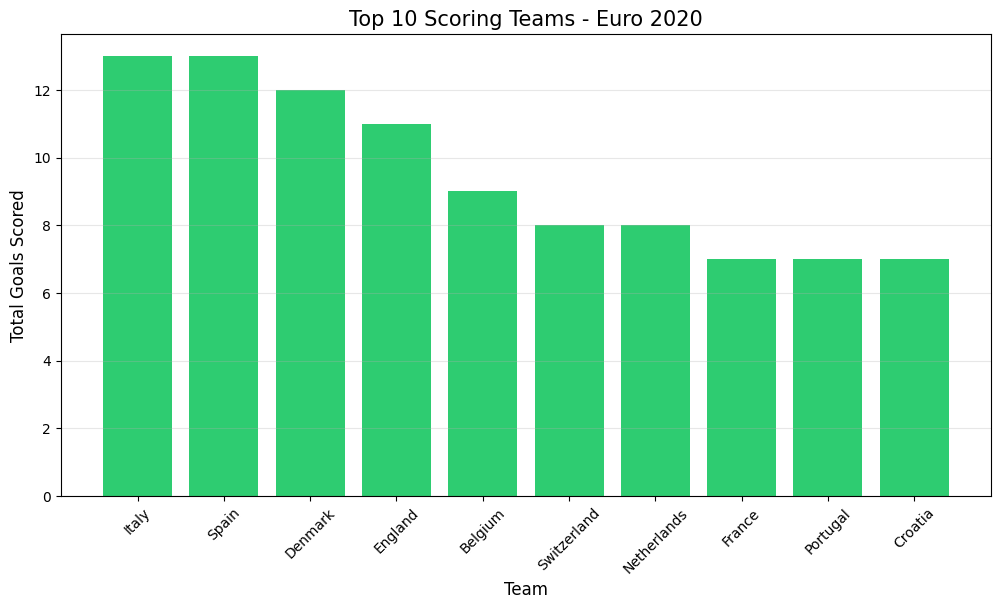

In [50]:
import matplotlib.pyplot as plt


pd_plot = total_goals_df.limit(10).toPandas()

plt.figure(figsize=(12,6))
plt.bar(pd_plot['Team'], pd_plot['TotalGoals'], color='#2ecc71') # Nice green color

plt.title('Top 10 Scoring Teams - Euro 2020', fontsize=15)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Total Goals Scored', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [51]:
from pyspark.sql import functions as F

player_attempts_raw = spark_df_3.filter(F.col("StatsName") == "Total Attempts")

player_stats = player_attempts_raw.select(
    "PlayerName",
    "PlayerSurname",
    F.coalesce(F.col("HomeTeamName"), F.col("AwayTeamName")).alias("Team"),
    F.col("Value").cast("int").alias("Player_Attempts")
)

master_df = player_stats.join(total_goals_df, on="Team", how="inner") \
    .orderBy(F.desc("Player_Attempts"))

master_df.show(10)

+-----------+----------+-------------+---------------+----------+
|       Team|PlayerName|PlayerSurname|Player_Attempts|TotalGoals|
+-----------+----------+-------------+---------------+----------+
|    Denmark|    Martin|  Braithwaite|              7|      12.0|
|Switzerland|   Xherdan|      Shaqiri|              7|       8.0|
|    Hungary|    Kylian|       Mbappé|              6|       3.0|
|    England|    Raheem|     Sterling|              6|      11.0|
|Netherlands|   Memphis|        Depay|              6|       8.0|
|     Sweden|      Emil|     Forsberg|              6|       5.0|
|     France|    Kylian|       Mbappé|              6|       7.0|
|   Scotland|    Patrik|       Schick|              6|       1.0|
|     Turkey|      Ciro|     Immobile|              6|       1.0|
|Switzerland|       nan|Gerard Moreno|              6|       8.0|
+-----------+----------+-------------+---------------+----------+
only showing top 10 rows



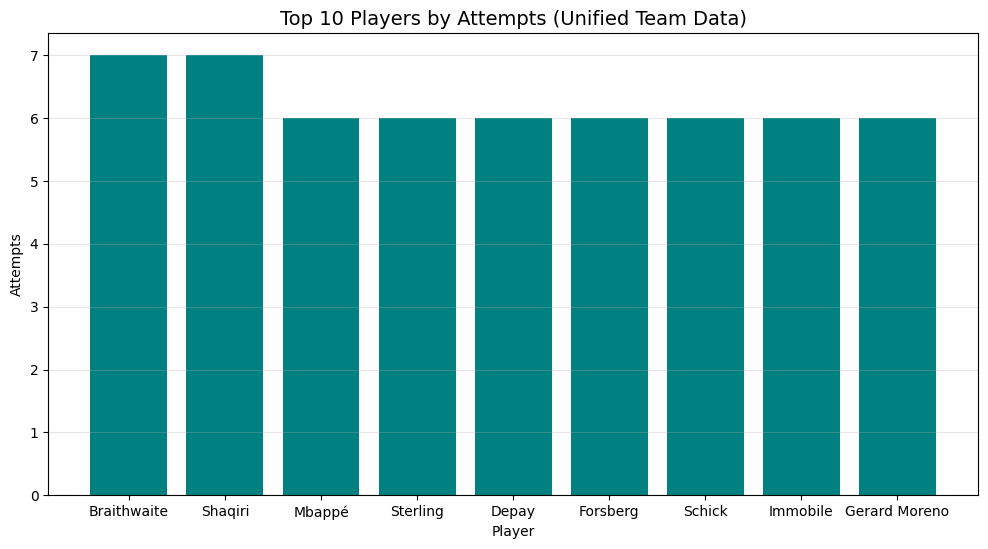

In [52]:
import matplotlib.pyplot as plt

pd_master = master_df.limit(10).toPandas()


plt.figure(figsize=(12, 6))
plt.bar(pd_master['PlayerSurname'], pd_master['Player_Attempts'], color='teal')

plt.title('Top 10 Players by Attempts (Unified Team Data)', fontsize=14)
plt.ylabel('Attempts')
plt.xlabel('Player')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [63]:
from pyspark.sql import functions as F


home_g = spark_df_1.groupBy("HomeTeamName").agg(F.sum("ScoreHome").alias("HG"))
away_g = spark_df_1.groupBy("AwayTeamName").agg(F.sum("ScoreAway").alias("AG"))

team_goals = home_g.join(away_g, home_g.HomeTeamName == away_g.AwayTeamName, "outer") \
    .select(
        F.coalesce(F.col("HomeTeamName"), F.col("AwayTeamName")).alias("Team"),
        (F.nanvl(F.col("HG"), F.lit(0)) + F.nanvl(F.col("AG"), F.lit(0))).alias("TotalGoals")
    )


team_attempts = spark_df_3.filter(F.lower(F.col("StatsName")).contains("attempts")) \
    .groupBy(F.coalesce(F.col("HomeTeamName"), F.col("AwayTeamName")).alias("Team")) \
    .agg(F.sum(F.col("Value").cast("int")).alias("TotalAttempts"))


clinical_teams_df = team_goals.join(team_attempts, "Team") \
    .withColumn("ConversionRate", F.round((F.col("TotalGoals") / F.col("TotalAttempts")) * 100, 2)) \
    .filter(F.col("TotalAttempts") > 0) \
    .orderBy(F.desc("ConversionRate"))

clinical_teams_df.show()

+---------------+----------+-------------+--------------+
|           Team|TotalGoals|TotalAttempts|ConversionRate|
+---------------+----------+-------------+--------------+
|          Spain|      13.0|          795|          1.64|
|        Denmark|      12.0|         1269|          0.95|
|         Poland|       4.0|          458|          0.87|
|        Germany|       6.0|          758|          0.79|
|        Austria|       5.0|          643|          0.78|
|        Belgium|       9.0|         1248|          0.72|
|         France|       7.0|         1072|          0.65|
|    Netherlands|       8.0|         1245|          0.64|
| Czech Republic|       6.0|          945|          0.63|
|        England|      11.0|         1777|          0.62|
|       Portugal|       7.0|         1136|          0.62|
|    Switzerland|       8.0|         1398|          0.57|
|          Italy|      13.0|         2399|          0.54|
|North Macedonia|       2.0|          467|          0.43|
|          Wal

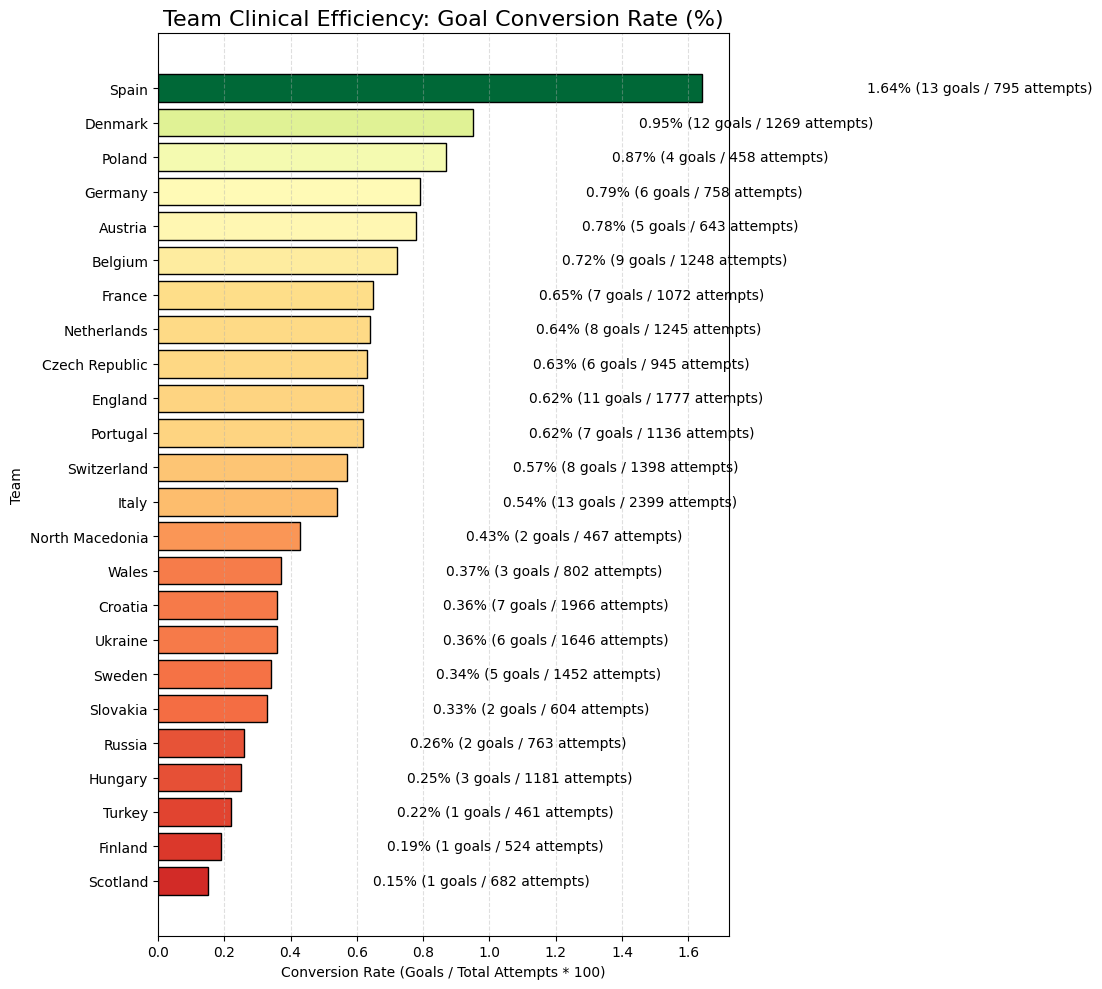

In [64]:
import matplotlib.pyplot as plt


pd_clinical = clinical_teams_df.orderBy(F.desc("ConversionRate")).toPandas()


plt.figure(figsize=(12, 10))


colors = plt.cm.RdYlGn(pd_clinical['ConversionRate'] / pd_clinical['ConversionRate'].max())
bars = plt.barh(pd_clinical['Team'], pd_clinical['ConversionRate'], color=colors, edgecolor='black')


for i, bar in enumerate(bars):
    goals = int(pd_clinical['TotalGoals'][i])
    attempts = int(pd_clinical['TotalAttempts'][i])
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{pd_clinical["ConversionRate"][i]}% ({goals} goals / {attempts} attempts)', 
             va='center', fontsize=10)

plt.title('Team Clinical Efficiency: Goal Conversion Rate (%)', fontsize=16)
plt.xlabel('Conversion Rate (Goals / Total Attempts * 100)')
plt.ylabel('Team')
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [65]:
from pyspark.sql import functions as F


passing_df = spark_df_3.filter(F.lower(F.col("StatsName")).contains("pass")) \
    .groupBy(F.coalesce(F.col("HomeTeamName"), F.col("AwayTeamName")).alias("Team")) \
    .agg(
        F.sum(F.when(F.col("StatsName") == "Passes attempted", F.col("Value")).otherwise(0)).alias("Attempted"),
        F.sum(F.when(F.col("StatsName") == "Passes completed", F.col("Value")).otherwise(0)).alias("Completed")
    ) \
    .withColumn("PassAccuracy", F.round((F.col("Completed") / F.col("Attempted")) * 100, 2)) \
    .orderBy(F.desc("PassAccuracy"))

passing_df.show(5)

+-----------+---------+---------+------------+
|       Team|Attempted|Completed|PassAccuracy|
+-----------+---------+---------+------------+
|   Portugal|   2180.0|   1973.0|        90.5|
|     France|   2406.0|   2101.0|       87.32|
|    Finland|   1237.0|   1078.0|       87.15|
|Switzerland|   2377.0|   2062.0|       86.75|
|   Slovakia|   1050.0|    908.0|       86.48|
+-----------+---------+---------+------------+
only showing top 5 rows



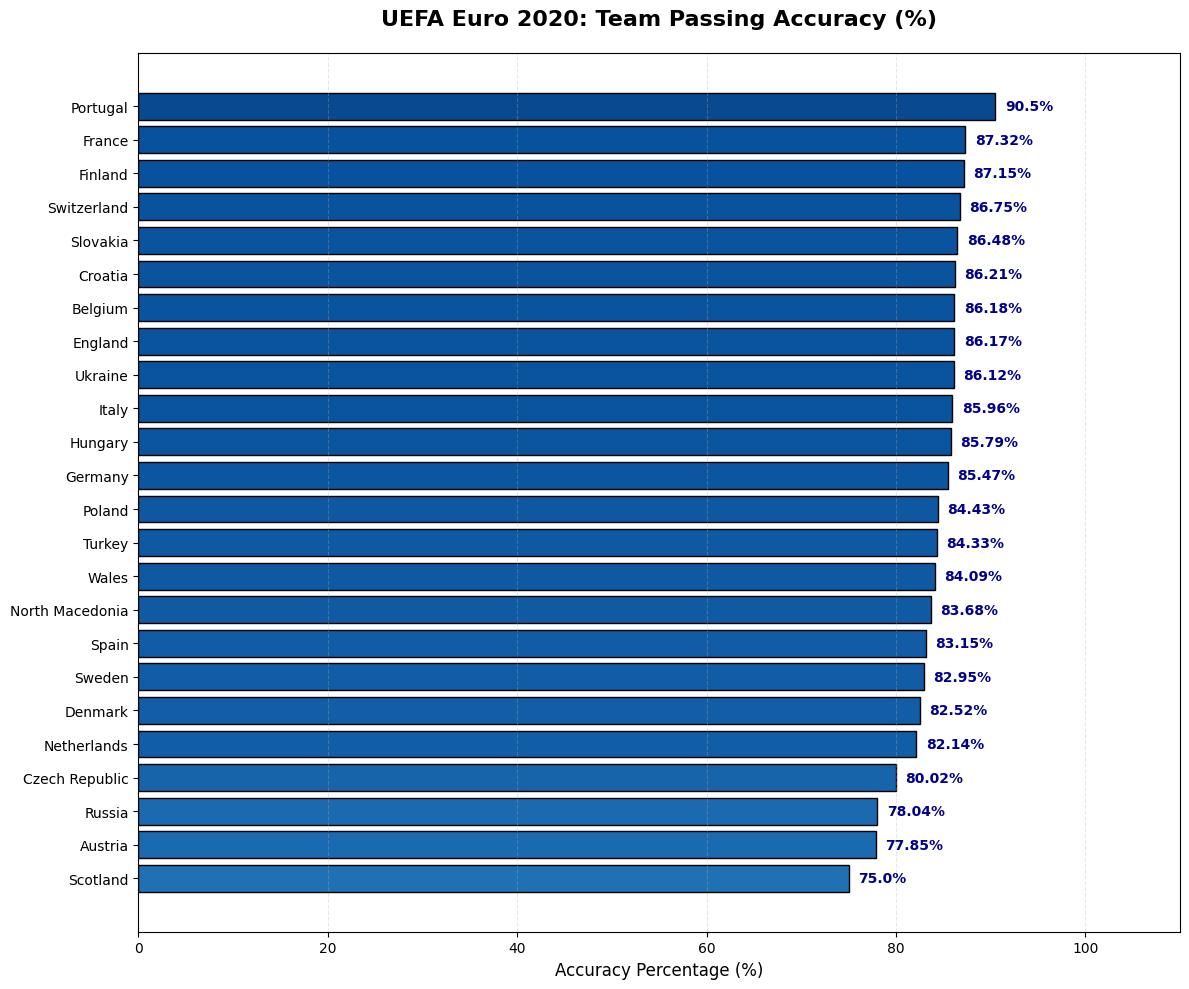

In [68]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F


passing_df = spark_df_3.filter(F.lower(F.col("StatsName")).contains("pass")) \
    .groupBy(F.coalesce(F.col("HomeTeamName"), F.col("AwayTeamName")).alias("Team")) \
    .agg(
        F.sum(F.when(F.col("StatsName") == "Passes attempted", F.col("Value").cast("int")).otherwise(0)).alias("Attempted"),
        F.sum(F.when(F.col("StatsName") == "Passes completed", F.col("Value").cast("int")).otherwise(0)).alias("Completed")
    ) \
    .withColumn("PassAccuracy", F.round((F.col("Completed") / F.col("Attempted")) * 100, 2)) \
    .orderBy(F.desc("PassAccuracy"))


pd_passing = passing_df.toPandas().sort_values('PassAccuracy', ascending=True)

plt.figure(figsize=(12, 10))
colors = plt.cm.Blues(pd_passing['PassAccuracy'] / 100) # Scale color by percentage
bars = plt.barh(pd_passing['Team'], pd_passing['PassAccuracy'], color=colors, edgecolor='black')


for i, bar in enumerate(bars):
    acc = pd_passing['PassAccuracy'].iloc[i]
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{acc}%', va='center', fontweight='bold', color='darkblue')

plt.title('UEFA Euro 2020: Team Passing Accuracy (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Accuracy Percentage (%)', fontsize=12)
plt.xlim(0, 110) 
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()